# Obstacle Pipeline — SAM3 + Vehicle + DA3 (simple)

| Step | What happens |
|---|---|
| 1 | Load image |
| 2 | Run SAM3, vehicle model, DA3 — sequential **and** parallel methods |
| 3 | Subplot: original / SAM3 / vehicle / DA3 |
| 4 | Car mask from vehicle model vs SAM3, side by side |
| 5 | Filter background SAM3 masks by car average depth (before / after) |
| 6 | Rules section — pluggable hooks (currently one: obstacle overlaps **filled** car region >= 5% of obstacle area) |
| 7 | Run obstacle check with enabled rules + plot car & obstacle masks |
| 8 | Final verdict `{"obstacle_exist": bool}` |

**Depth convention:** DA3 returns metric depth -> **smaller value = closer**.
A foreground object has mean depth **smaller** than the car's average depth.

## 0 · Config & paths

In [ ]:
import os, sys, time, json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from concurrent.futures import ThreadPoolExecutor

# ── server paths (Azure GPU server) ──────────────────────────────────────────
BASE_PATH       = "/mnt/aitraining/krishna/2026/obstacle_pipeline"
TEST_IMAGES_DIR = os.path.join(BASE_PATH, "test_images")
OBSTACLE_DIR    = os.path.join(TEST_IMAGES_DIR, "obstacle")
SAM3_WEIGHTS    = "sam3.pt"
DA3_REPO        = os.path.join(BASE_PATH, "Depth-Anything-3")
DA3_MODEL_NAME  = "depth-anything/DA3-LARGE-1.1"
DA3_CACHE_DIR   = os.path.join(BASE_PATH, "da3_model")
VEHICLE_WEIGHTS = os.path.join(BASE_PATH, "vehicle_model",
                               "vehicle_detection_yolov11m_segm_v3_1.pt")  # YOLOv11m-seg

CFG = dict(
    sam3_text_prompts = [
        "car", "person", "child", "bicycle", "motorcycle", "stroller", "wheelchair",
        "shopping cart", "trolley", "dog", "cat", "animal", "traffic cone",
        "pole", "bollard", "trash can", "box", "bag", "ladder", "chair",
        "plant", "bush", "ball", "toy",
    ],
    sam3_conf           = 0.25,
    min_car_overlap_pct = 5.0,   # rule: % of the obstacle's area inside the filled car region (1-100)
)

# ── pick a test image ─────────────────────────────────────────────────────────
images = sorted(f for f in os.listdir(OBSTACLE_DIR) if f.endswith((".png", ".jpg")))
print(f"Obstacle images available: {len(images)}")
for i, n in enumerate(images):
    print(f"  [{i}] {n}")

IMAGE_INDEX = 1       # <- change to try different images
IMAGE_PATH  = os.path.join(OBSTACLE_DIR, images[IMAGE_INDEX])
print(f"\nSelected: {IMAGE_PATH}")

## 1 · Load image

Image size: 607 x 1080  |  614bafa7-a4ca-4abd-ba7e-9ba3b1c72166.png


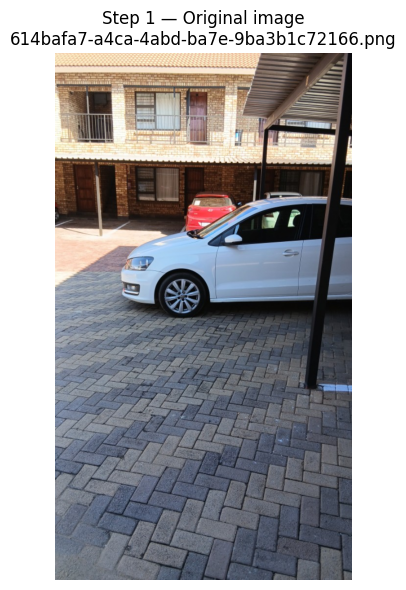

In [16]:
original_bgr = cv2.imread(IMAGE_PATH, cv2.IMREAD_COLOR)
original_img = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
oh, ow = original_img.shape[:2]
print(f"Image size: {ow} x {oh}  |  {os.path.basename(IMAGE_PATH)}")

plt.figure(figsize=(10, 6))
plt.imshow(original_img)
plt.title(f"Step 1 — Original image\n{os.path.basename(IMAGE_PATH)}", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

## 2 · Model inference — sequential vs parallel

Models are loaded once, then two methods are provided:

- `run_models_sequential()` — SAM3 -> vehicle -> DA3, one by one
- `run_models_parallel()` — all three submitted to a thread pool at the same time

In [11]:
# ── load the three models once ────────────────────────────────────────────────
from ultralytics import YOLO
from ultralytics.models.sam import SAM3SemanticPredictor

os.environ["HF_HOME"] = os.environ.get("HF_HOME", DA3_CACHE_DIR)
if DA3_REPO not in sys.path:
    sys.path.append(DA3_REPO)
from depth_anything_3.api             import DepthAnything3
from depth_anything_3.utils.visualize import visualize_depth

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

sam3_predictor = SAM3SemanticPredictor(overrides=dict(
    model   = SAM3_WEIGHTS,
    conf    = CFG["sam3_conf"],
    task    = "segment",
    mode    = "predict",
    half    = True,
    verbose = False,
    save    = False,
    imgsz   = 644,     # nearest multiple of SAM3's stride-14 above 640
))
veh_model = YOLO(VEHICLE_WEIGHTS)
da3_model = DepthAnything3.from_pretrained(DA3_MODEL_NAME).to(device=device)
print("Models loaded: SAM3, vehicle YOLOv11m-seg, DA3")

Device: cuda
[INFO ] using MLP layer as FFN
Models loaded: SAM3, vehicle YOLOv11m-seg, DA3


In [17]:
# ── per-model inference functions ─────────────────────────────────────────────
def run_sam3(image_path):
    sam3_predictor.set_image(image_path)
    res = sam3_predictor(text=CFG["sam3_text_prompts"])
    return res[0] if isinstance(res, (list, tuple)) else res

def run_vehicle(image_path):
    return veh_model(image_path, conf=0.1, iou=0.6, max_det=1, verbose=False)[0]

def run_da3(image_rgb):
    res = da3_model.inference([image_rgb])
    return res.depth[0] if res.depth.ndim == 3 else res.depth

# ── method 1: one by one ──────────────────────────────────────────────────────
def run_models_sequential(image_path, image_rgb):
    return run_sam3(image_path), run_vehicle(image_path), run_da3(image_rgb)

# ── method 2: in parallel ─────────────────────────────────────────────────────
def run_models_parallel(image_path, image_rgb):
    with ThreadPoolExecutor(max_workers=3) as ex:
        f_sam = ex.submit(run_sam3,    image_path)
        f_veh = ex.submit(run_vehicle, image_path)
        f_da3 = ex.submit(run_da3,     image_rgb)
        return f_sam.result(), f_veh.result(), f_da3.result()

# ── run both and compare timing (parallel results are used downstream) ───────
t0 = time.perf_counter()
sam_res, veh_res, depth_map = run_models_sequential(IMAGE_PATH, original_img)
t_seq = time.perf_counter() - t0

t0 = time.perf_counter()
sam_res, veh_res, depth_map = run_models_parallel(IMAGE_PATH, original_img)
t_par = time.perf_counter() - t0

print(f"Sequential: {t_seq:.2f} s   |   Parallel: {t_par:.2f} s")

img_h, img_w = depth_map.shape
sam_masks_raw = sam_res.masks.data.cpu().numpy() if sam_res.masks is not None else np.array([])
n_masks = len(sam_masks_raw)
print(f"SAM3 masks: {n_masks}   |   vehicle detections: "
      f"{len(veh_res.boxes) if veh_res.boxes is not None else 0}   |   "
      f"depth map: {depth_map.shape}  min={depth_map.min():.3f} m  max={depth_map.max():.3f} m")

[INFO ] Processed Images Done taking 0.013070344924926758 seconds. Shape:  torch.Size([1, 3, 504, 280])
[INFO ] Model Forward Pass Done. Time: 0.30597519874572754 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0007557868957519531 seconds
[INFO ] Processed Images Done taking 0.018010854721069336 seconds. Shape:  torch.Size([1, 3, 504, 280])
[INFO ] Model Forward Pass Done. Time: 0.46008753776550293 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0010826587677001953 seconds
Sequential: 1.42 s   |   Parallel: 1.20 s
SAM3 masks: 14   |   vehicle detections: 1   |   depth map: (504, 280)  min=0.293 m  max=2.171 m


## 3 · Results subplot — original / SAM3 / vehicle / DA3

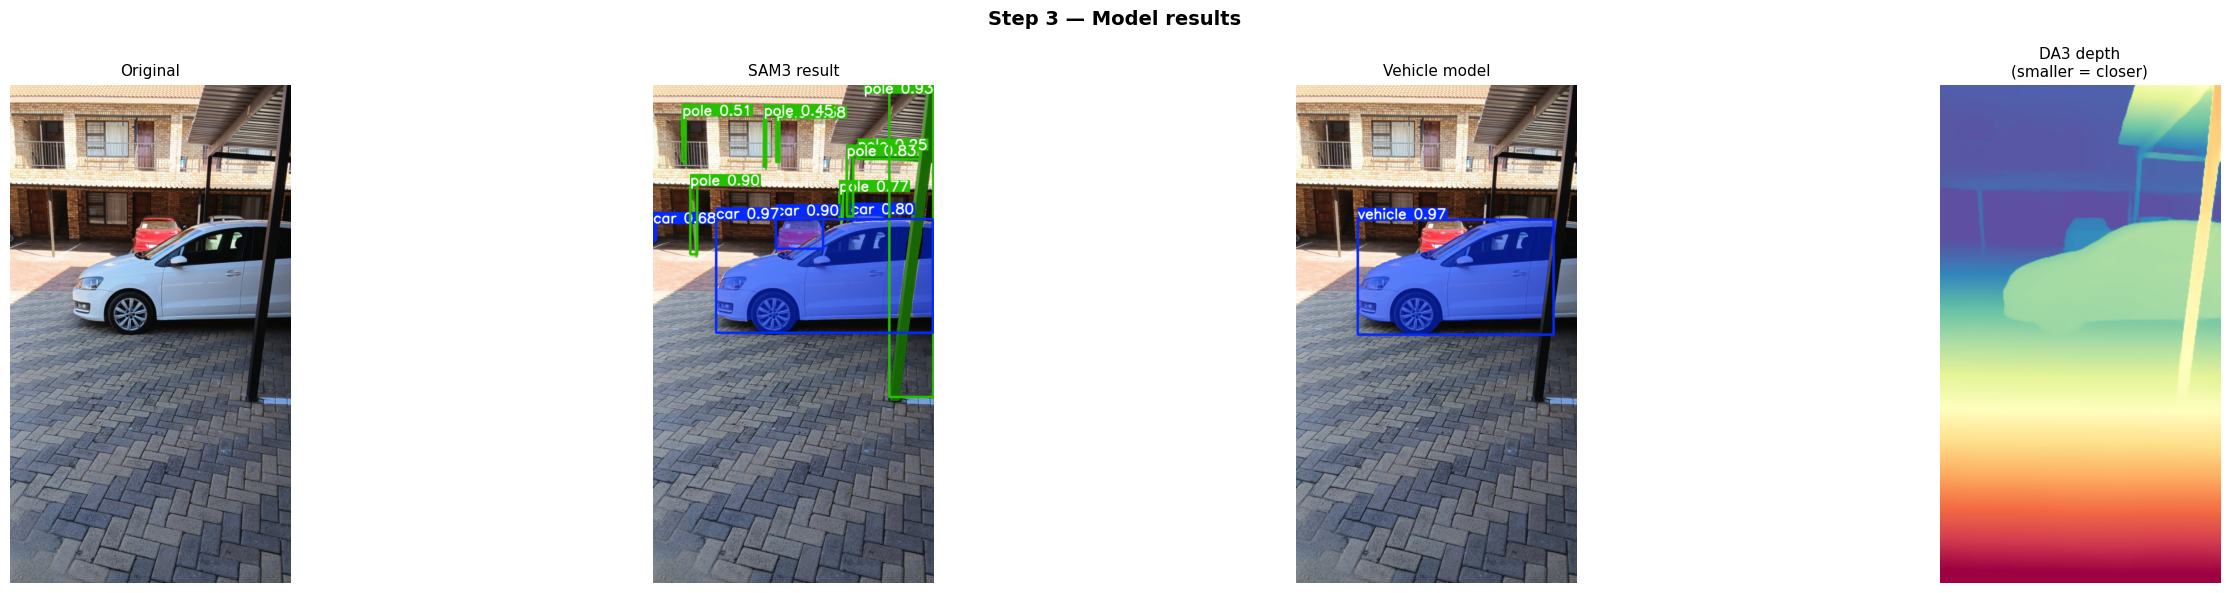

In [18]:
sam_img_disp = cv2.resize(cv2.cvtColor(sam_res.plot(), cv2.COLOR_BGR2RGB), (ow, oh))
veh_img_disp = cv2.resize(cv2.cvtColor(veh_res.plot(), cv2.COLOR_BGR2RGB), (ow, oh))
da3_disp     = cv2.resize(visualize_depth(depth_map), (ow, oh))

fig, axes = plt.subplots(1, 4, figsize=(28, 6))
axes[0].imshow(original_img); axes[0].set_title("Original",          fontsize=11)
axes[1].imshow(sam_img_disp); axes[1].set_title("SAM3 result",       fontsize=11)
axes[2].imshow(veh_img_disp); axes[2].set_title("Vehicle model",     fontsize=11)
axes[3].imshow(da3_disp);     axes[3].set_title("DA3 depth\n(smaller = closer)", fontsize=11)
for ax in axes: ax.axis("off")
plt.suptitle("Step 3 — Model results", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## 4 · Car mask — vehicle model vs SAM3

The vehicle car mask comes from the YOLO segmentation head.
The SAM3 car mask is the SAM3 mask with the **highest IoU** against the vehicle mask.

SAM3 car mask: #0  (IoU vs vehicle mask = 0.847)


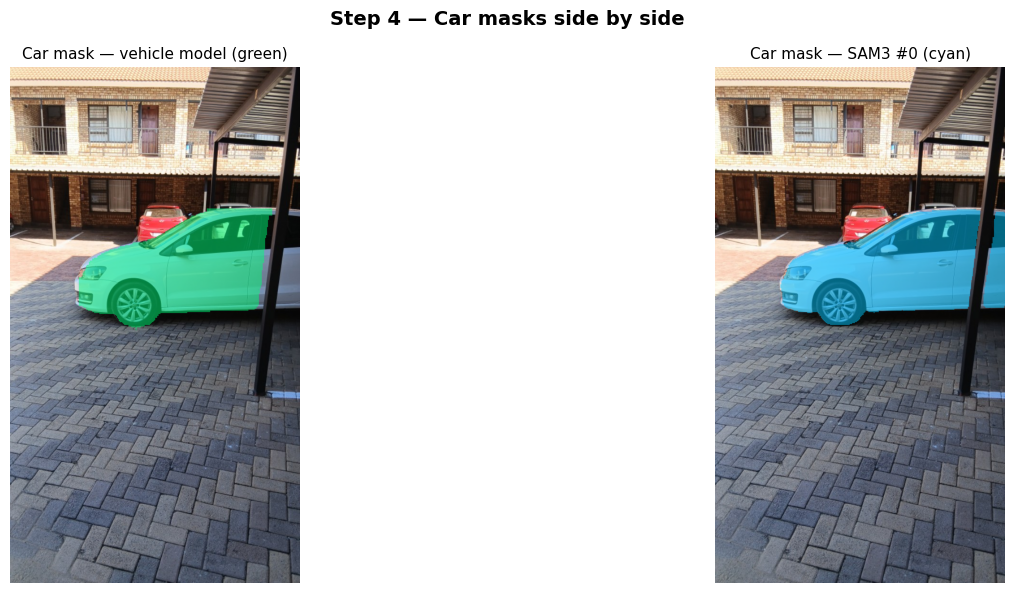

In [19]:
CAR_COLOR = np.array([0, 200, 255])    # cyan  — SAM3 car mask
VEH_COLOR = np.array([0, 255, 120])    # green — vehicle model mask

def overlay_mask(img, mask_hw, color, alpha=0.5):
    out = img.copy()
    mr  = cv2.resize(mask_hw.astype(np.uint8), (img.shape[1], img.shape[0]),
                     interpolation=cv2.INTER_NEAREST).astype(bool)
    out[mr] = (out[mr] * (1 - alpha) + np.array(color) * alpha).astype(np.uint8)
    return out

# ── vehicle car mask (segmentation head, bbox fallback) ───────────────────────
veh_car_mask = None
if veh_res.boxes is not None and len(veh_res.boxes) > 0:
    if veh_res.masks is not None and len(veh_res.masks) > 0:
        vm = veh_res.masks.data[0].cpu().numpy()
        if vm.shape != (img_h, img_w):
            vm = cv2.resize(vm.astype(np.uint8), (img_w, img_h), interpolation=cv2.INTER_NEAREST)
        veh_car_mask = vm > 0.5
    else:
        x1, y1, x2, y2 = map(int, veh_res.boxes.xyxy[0].cpu().numpy())
        veh_car_mask = np.zeros((img_h, img_w), dtype=bool)
        veh_car_mask[y1:y2, x1:x2] = True
assert veh_car_mask is not None and veh_car_mask.any(), "Vehicle model found no car"

# ── SAM3 masks at depth-map resolution ────────────────────────────────────────
sam_masks = np.array([
    cv2.resize(m.astype(np.uint8), (img_w, img_h), interpolation=cv2.INTER_NEAREST)
    for m in sam_masks_raw
]) if n_masks > 0 else np.array([])

# ── SAM3 car mask = highest IoU vs the vehicle mask ───────────────────────────
best_iou, car_idx = 0.0, -1
for i, m in enumerate(sam_masks):
    sb    = m > 0.5
    inter = np.logical_and(veh_car_mask, sb).sum()
    union = np.logical_or(veh_car_mask,  sb).sum()
    iou   = inter / union if union > 0 else 0.0
    if iou > best_iou:
        best_iou, car_idx = iou, i
assert car_idx != -1, "No SAM3 mask matches the vehicle region"

sam_car_mask = sam_masks[car_idx] > 0.5
print(f"SAM3 car mask: #{car_idx}  (IoU vs vehicle mask = {best_iou:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(overlay_mask(original_img, veh_car_mask, VEH_COLOR))
axes[0].set_title("Car mask — vehicle model (green)", fontsize=11)
axes[1].imshow(overlay_mask(original_img, sam_car_mask, CAR_COLOR))
axes[1].set_title(f"Car mask — SAM3 #{car_idx} (cyan)", fontsize=11)
for ax in axes: ax.axis("off")
plt.suptitle("Step 4 — Car masks side by side", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## 5 · Filter background SAM3 masks by car depth

Average metric depth of the SAM3 car mask is the reference.
A mask is **foreground** when its mean depth is **smaller** (= closer) than the car's.

Car average depth = 0.764 m
  mask 1: mean_depth=0.491 m  -> FOREGROUND
  mask 2: mean_depth=1.330 m  -> background
  mask 3: mean_depth=1.595 m  -> background
  mask 4: mean_depth=1.319 m  -> background
  mask 5: mean_depth=1.405 m  -> background
  mask 6: mean_depth=1.599 m  -> background
  mask 7: mean_depth=2.024 m  -> background
  mask 8: mean_depth=1.900 m  -> background
  mask 9: mean_depth=1.873 m  -> background
  mask 10: mean_depth=1.913 m  -> background
  mask 11: mean_depth=1.860 m  -> background
  mask 12: mean_depth=1.871 m  -> background
  mask 13: mean_depth=1.135 m  -> background

Foreground masks kept: [1]  |  background dropped: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


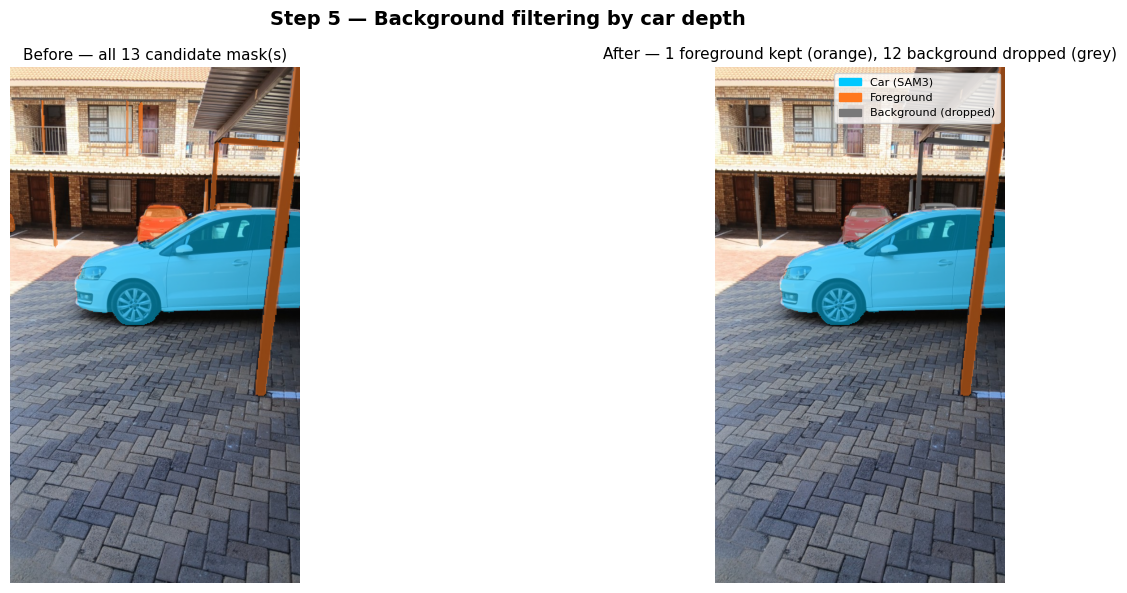

In [20]:
car_depth = float(np.mean(depth_map[sam_car_mask]))
print(f"Car average depth = {car_depth:.3f} m")

candidates = [i for i in range(n_masks) if i != car_idx]
foreground_indices, background_indices = [], []
for i in candidates:
    sb = sam_masks[i] > 0.5
    md_ = float(np.mean(depth_map[sb]))
    (foreground_indices if md_ < car_depth else background_indices).append(i)
    print(f"  mask {i}: mean_depth={md_:.3f} m  -> {'FOREGROUND' if md_ < car_depth else 'background'}")

print(f"\nForeground masks kept: {foreground_indices}  |  background dropped: {background_indices}")

# ── before / after ────────────────────────────────────────────────────────────
FG_COLOR = np.array([255, 120, 30])    # orange
BG_COLOR = np.array([120, 120, 120])   # grey

before_img = overlay_mask(original_img, sam_car_mask, CAR_COLOR)
for i in candidates:
    before_img = overlay_mask(before_img, sam_masks[i] > 0.5, FG_COLOR, alpha=0.55)

after_img = overlay_mask(original_img, sam_car_mask, CAR_COLOR)
for i in background_indices:
    after_img = overlay_mask(after_img, sam_masks[i] > 0.5, BG_COLOR, alpha=0.55)
for i in foreground_indices:
    after_img = overlay_mask(after_img, sam_masks[i] > 0.5, FG_COLOR, alpha=0.55)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(before_img)
axes[0].set_title(f"Before — all {len(candidates)} candidate mask(s)", fontsize=11)
axes[1].imshow(after_img)
axes[1].set_title(f"After — {len(foreground_indices)} foreground kept (orange), "
                  f"{len(background_indices)} background dropped (grey)", fontsize=11)
for ax in axes: ax.axis("off")
patches = [mpatches.Patch(color=CAR_COLOR/255, label="Car (SAM3)"),
           mpatches.Patch(color=FG_COLOR/255,  label="Foreground"),
           mpatches.Patch(color=BG_COLOR/255,  label="Background (dropped)")]
axes[1].legend(handles=patches, loc="upper right", fontsize=8)
plt.suptitle("Step 5 — Background filtering by car depth", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## 6 · Rules — pluggable hooks

Each rule is a function `(mask_bin, ctx) -> (passed, detail)` registered in `RULES`.
Pick which ones run via `ENABLED_RULES`; a mask is an obstacle when **all** enabled rules pass.

Currently one rule:

- `car_overlap` — the foreground mask must overlap the **filled** SAM3 car mask
  by >= `CFG["min_car_overlap_pct"]` of the **obstacle's own area**.

Why filled: SAM3 masks are mutually exclusive, so an occluder's pixels are carved
*out* of the car mask (raw intersection is ~0 even for a pole right in front of the
car). `fill_instance_mask()` takes the convex hull over all car-mask components —
if the occluder split the car into separate blobs, they are bridged back into one
filled instance — and the obstacle is tested against that amodal region.

In [ ]:
RULES = {}

def rule(name):
    def deco(fn):
        RULES[name] = fn
        return fn
    return deco

def fill_instance_mask(mask_bin):
    """Amodal car region: convex hull over all components of the mask.

    SAM3 masks are mutually exclusive, so an occluder (e.g. a pole) carves its
    pixels out of the car mask — sometimes splitting it into separate blobs.
    The hull bridges those blobs and fills the carved-out gap, recovering the
    region the car *would* cover if nothing stood in front of it.
    """
    m = mask_bin.astype(np.uint8)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return mask_bin
    hull = cv2.convexHull(np.vstack([c.reshape(-1, 2) for c in contours]))
    filled = np.zeros_like(m)
    cv2.fillConvexPoly(filled, hull, 1)
    return filled.astype(bool)

@rule("car_overlap")
def rule_car_overlap(mask_bin, ctx):
    area        = mask_bin.sum()
    inter       = np.logical_and(mask_bin, ctx["car_mask_filled"]).sum()
    overlap_pct = 100.0 * inter / area if area > 0 else 0.0
    passed      = overlap_pct >= ctx["cfg"]["min_car_overlap_pct"]
    return passed, (f"overlap={overlap_pct:.2f}% of obstacle "
                    f"(min={ctx['cfg']['min_car_overlap_pct']:.0f}%)")

# add future rules here with @rule("...") and enable them below
ENABLED_RULES = ["car_overlap"]
print(f"Registered rules: {list(RULES)}   |   enabled: {ENABLED_RULES}")

## 7 · Run obstacle check with enabled rules

In [ ]:
sam_car_mask_filled = fill_instance_mask(sam_car_mask)
ctx = dict(car_mask=sam_car_mask, car_mask_filled=sam_car_mask_filled,
           depth_map=depth_map, cfg=CFG)

obstacle_indices = []
for i in foreground_indices:
    sb = sam_masks[i] > 0.5
    verdicts = {name: RULES[name](sb, ctx) for name in ENABLED_RULES}
    ok = all(p for p, _ in verdicts.values())
    detail = "  ".join(f"[{n}] {'PASS' if p else 'REJECT'} {d}" for n, (p, d) in verdicts.items())
    print(f"  mask {i}: {detail}")
    if ok:
        obstacle_indices.append(i)

obstacle_exist = len(obstacle_indices) > 0
print(f"\nObstacle masks: {obstacle_indices}  ->  obstacle_exist={obstacle_exist}")

# ── plot filled car region + car mask + obstacle masks ────────────────────────
OBSTACLE_C = np.array([255, 0, 0])
FILLED_C   = np.array([255, 255, 0])
result_img = overlay_mask(original_img, sam_car_mask_filled & ~sam_car_mask, FILLED_C, alpha=0.25)
result_img = overlay_mask(result_img, sam_car_mask, CAR_COLOR)
for i in obstacle_indices:
    result_img = overlay_mask(result_img, sam_masks[i] > 0.5, OBSTACLE_C, alpha=0.6)

plt.figure(figsize=(12, 7))
plt.imshow(result_img)
title = (f"Obstacle(s) overlapping car: masks {obstacle_indices}" if obstacle_exist
         else "No obstacle overlapping the car")
plt.title(f"Step 7 — {title}", fontsize=13, fontweight="bold",
          color="red" if obstacle_exist else "green")
plt.legend(handles=[mpatches.Patch(color=CAR_COLOR/255,  label="Car mask (SAM3)"),
                    mpatches.Patch(color=FILLED_C/255,   label="Filled car region (hull)"),
                    mpatches.Patch(color=OBSTACLE_C/255, label="Obstacle mask")],
           loc="upper right", fontsize=9)
plt.axis("off"); plt.tight_layout(); plt.show()

## 8 · Final verdict

In [ ]:
print(json.dumps({"obstacle_exist": bool(obstacle_exist)}))